# 02_VAE_FashionMNIST

Gonzalo Cazorla Sánchez

Uno de los primeros modelos propuestos para la generación de datos usando Aprendizaje profundo fue el *Variational Autoencoder* (VAE).

Un VAE es una red autocodificadora que durante su entrenamiento, en lugar de codificar a un espacio latente de manera determinista (cada ejemplo tiene asociada una codificación), asocia distribuciones gaussianas que se muestrean para obtener una codificación que seguidamente se decodifica. Por tanto, el proceso queda como sigue:

$$\mu, \sigma^2 = e_{\theta_1}(x)$$

$$z \sim \mathcal{N}(\mu, \sigma^2) $$

$$y = d_{\theta_{2}} (z)$$

Para realizar el entrenamiento como cualquier red autocodificadora, se incluye una función de pérdida de reconstrucción:

$$L_{r}(x,y)$$

Pero además se añade una función de pérdida con el objetivo de regularizar las distribuciones gaussianas que pueden aprenderse. Para esto se usa la Divergencia de Kullback-Leibler, que mide el grado de disimilitud entre una distribución de probabilidad $Q$ respecto a una distribución de probabilidad $P$:

$$D_{KL}(P,Q) = \sum_{x \in X} P(x) log (\frac{P(x)}{Q(x)})$$

La divergencia KL se utiliza para penalizar que las distribuciones gaussianas se alejen de la distribución gaussiana de media 0 y varianza 1 ($\mathcal{N}(0, 1)$). Teniendo eso en cuenta, su formulación se puede simplificar a:

$$L_{KL}(\mu, \sigma)= \sum_{i=0}^n -\frac{1}{2}(1+log (\sigma_i^2) - \mu_i^2 - \sigma_i^2)$$

Siendo la función de pérdida que se usa durante el entrenamiento:

$$L = L_{r} + \alpha L_{KL}$$

con $\alpha$ un hiperparámetro que controla cuánto peso tiene la divergencia de Kullback-Leibler respecto a la pérdida de reconstrucción.

Tras implementar el VAE, se pide entrenarlo para los datos de  Fashion-MNIST con un espacio latente de 8 dimensiones (el vector $\mu$ y el que representa sus respectivas varianzas tienen 8 dimensiones cada uno). Una vez entrenado y comprobado debidamente que funciona, se pide mostrar las componentes del vector $\mu$ del conjunto de test en el espacio latente usando gráficas bidimensionales que indican la clase de cada ejemplo como en el Ejercicio 1.

Después, se debe extraer el vector prototípico para cada clase en el conjunto de test (la media de los vectores $\mu$ para cada clase) y mostrar las imágenes generadas por el decodificador a partir de las codificaciones interpoladas entre los vectores prototípicos de dos clases cualesquiera.

El cuaderno entregado debe llamarse ApellidosNombrePractica3Ejercicio2.ipynb

Notas:
 * Para realizar el muestreo $z$ permitiendo la retropropagación del error se usa el "truco de reparametrización": no muestrear directamente la distribución gaussiana obtenida (eso rompería el grafo de cómputo), sino la distribución gaussiana $\hat{z} \sim \mathcal{N}(0, 1)$ y aprovechar la propiedad de las gaussianas para convertir el muestreo de una distribución gaussiana en el de otra para que (una vez simplificado aprovechando que se muestrea la normal) quede  $z =  \hat{z} \sigma + \mu$.
 * Es más fácil (y equivalente) que el encoder genere el logaritmo de la varianza en lugar de la varianza. Así se evita la posibilidad de intentar computar un $log(0)$. Obviamente hay que ajustar las fórmulas que se implementan de manera acorde.
 * Aunque PyTorch implementa diversas funciones para calcular la divergencia KL, ninguna está directamente pensada para este uso y su aplicación no es directa, así que es más fácil simplemente implementarla. Hay que recordar usar los operadores de PyTorch para que se genere el grafo de cómputo sin problema y que la pérdida de un lote debe ser la media de las pérdidas de los ejemplos que lo forman.
 * El valor $\alpha$ para conseguir un entrenamiento apropiado puede ser muy bajo según el conjunto de datos al que se aplique (incluso menos de 0.01).

In [85]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F
import torchvision.transforms.functional as Fn
import numpy as np
import os
import csv

In [86]:
from google.colab import drive
drive.mount('/content/drive')
workpath = '/content/drive/MyDrive/PIA/PRACTICA3EJ2'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
# Detectar si hay GPU disponible (CUDA) o usar CPU si no
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


In [88]:
class CudaDataset(Dataset):
  def __init__(self, dataset, device, transform = None):
    self.dataset = dataset
    self.cuda_y = []
    self.cuda_x = []
    self.device = device
    self.transform = transform

    for x, y in tqdm(self.dataset, desc="Moving to GPU"):
      x_flat = torch.flatten(x).to(self.device)    # x viene como [1, 28, 28] => [784]
      self.cuda_x.append(x_flat)
      self.cuda_y.append(torch.tensor(y, device=self.device))

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    if self.transform is None:
      x = self.cuda_x[idx]
    else:
      x = self.transform(self.cuda_x[idx])
    return x, self.cuda_y[idx]

def split_dataset(dataset, split_share=0.1):
  """
  Devuelve dos subconjuntos del dataset. split_share define cuántos ejemplos irán al
  primer subconjunto. El resto irán al segundo.
  """
  mask_indices_to_first_subset = torch.rand(len(dataset))<=split_share
  indices_first_subset = [i for i, (_, _) in enumerate(dataset) if mask_indices_to_first_subset[i]]
  indices_second_subset = [i for i, (_, _) in enumerate(dataset) if not mask_indices_to_first_subset[i]]

  first_subset = torch.utils.data.Subset(dataset, indices_first_subset)
  second_subset = torch.utils.data.Subset(dataset, indices_second_subset)

  return first_subset, second_subset

In [89]:
# Esta es la política de aumentación.
augmentation_policy = transforms.Compose([
                          transforms.ToTensor(),
                          transforms.RandomHorizontalFlip(p=0.5),])

train_dataset = datasets.FashionMNIST(root=workpath, train=True, download=True, transform=augmentation_policy)
test_dataset = datasets.FashionMNIST(root=workpath, train=False, download=True, transform=transforms.ToTensor())

val_dataset, train_dataset = split_dataset(train_dataset)
print(f"Número de ejemplos en entrenamiento:  {len(train_dataset)}")
print(f"Número de ejemplos en validación:     {len(val_dataset)}")
print(f"Número de ejemplos en test:           {len(test_dataset)}")

Número de ejemplos en entrenamiento:  54074
Número de ejemplos en validación:     5926
Número de ejemplos en test:           10000


In [90]:
# Pasamos los dataset a CUDA
if not str(device)=="cpu":
  train_dataset = CudaDataset(train_dataset, device)
  val_dataset = CudaDataset(val_dataset, device)
  test_dataset = CudaDataset(test_dataset, device)

batch_size = 1024

# Creamos los DataLoader
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Moving to GPU: 100%|██████████| 10000/10000 [00:02<00:00, 4367.42it/s]


In [91]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()

        # ENCODER
        self.encoder_base = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Dos cabezas separadas para predecir media y log-varianza
        self.fc_mu = nn.Linear(64, latent_dim)      # Predice la media (mu)
        self.fc_logvar = nn.Linear(64, latent_dim)  # Predice log(sigma^2)

        # DECODER
        # El decoder es idéntico al anterior, toma 'z' y reconstruye la imagen
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()                      # Salida entre [0, 1] para píxeles
        )

    def reparameterize(self, mu, logvar):
        if self.training:
            sigma = torch.exp(0.5 * logvar)       # Obtener la desviación estándar (sigma): logvar = log(sigma^2) => sigma = exp(0.5 * logvar)
            z_gorrito = torch.randn_like(sigma)   # Muestrear epsilon de N(0, 1) con el mismo tamaño y dispositivo que sigma
            return z_gorrito * sigma + mu         # Calcular z = ẑ * σ + μ
        else:
            return mu

    def forward(self, x):
        h = self.encoder_base(x)              # Pasar por la base del encoder
        mu = self.fc_mu(h)                    # Obtener media
        logvar = self.fc_logvar(h)            # Obtener log-varianza
        z = self.reparameterize(mu, logvar)   # Muestrear z usando el truco de reparametrización
        reconstruction = self.decoder(z)      # Decodificar z para obtener la reconstrucción
        return reconstruction, mu, logvar

In [92]:
# Definimos la función de pérdida personalizada
def vae_loss_function(recon_x, x, mu, logvar, alpha=0.001):
    """
    Calcula la pérdida del VAE:
    Loss = (Error Reconstrucción + alpha * Divergencia KL) / Batch_Size
    """
    batch_size = x.shape[0]
    num_pixeles = x.shape[1]

    # 1. RECONSTRUCTION LOSS (he escogido el MSE)
    Lr = torch.sum((recon_x - x).pow(2)) / num_pixeles
    """
    Mide cuánto se equivoca la red en cada píxel
    - Si la imagen tiene 10.000 píxeles, sumar errores de todos ellos da un número enorme.
    - Si la imagen tiene 100.000 píxeles, la suma sería 10 veces mayor aunque la calidad sea igual.
    Para que Lr no dependa del tamaño de la imagen, lo divido entre num_pixeles.
    """

    # 2. KL DIVERGENCE
    LKL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())   # -0.5 * Σ(1 + log(σ^2) − μ^2 − σ^2)
    """
    Mide cuánto se parece la distribución latente al prior Normal(0,1)
    - Solo depende de los vectores mu y logvar del latente.
    - No cambia si la imagen es de 28×28, 64×64 o 256×256.
    Por eso no hace falta dividir la KL entre los píxeles.
    """


    # 3. TOTAL LOSS (por imagen)
    loss = (Lr + alpha * LKL) / batch_size                          # L = Lr + α * LKL
    return loss

In [93]:
def learning_loop_with_val(train_dataloader, val_dataloader, model, epochs, learning_rate, optimizer, validation_freq, alpha):
  train_loss_list = []
  val_loss_list = []
  opt = optimizer(
    model.parameters(),
    lr=learning_rate
  )
  with tqdm(range(epochs), desc="epoch") as pbar:
    for epoch in pbar:
      model.train()
      train_step_loss_list = []
      for image, _ in train_dataloader:
        image_recon, mu, logvar = model(image)              # Forward
        opt.zero_grad()
        loss = vae_loss_function(image_recon, image, mu, logvar, alpha)
        loss.backward()                                     # Backward
        train_step_loss_list.append(loss.clone().detach())
        opt.step()
      train_loss = torch.tensor(train_step_loss_list).mean()
      train_loss_list.append(train_loss)
      pbar.set_postfix(loss=f"{train_loss}")

      if epoch % validation_freq == 0:
        model.eval()
        val_step_loss_list = []
        with torch.no_grad():
          for image_val, _ in val_dataloader:
            image_val_recon, mu, logvar = model(image_val)
            loss_val = vae_loss_function(image_val_recon, image_val, mu, logvar, alpha)
            val_step_loss_list.append(loss_val)
          val_loss_list.append(torch.tensor(val_step_loss_list).mean())

  return train_loss_list, val_loss_list

In [94]:
alpha = 0.001
learning_rate = 1e-3
epochs = 1500
optimizer = torch.optim.Adam
validation_freq = 5
model = VariationalAutoencoder().to(device)
print(model)

VariationalAutoencoder(
  (encoder_base): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=784, bias=True)
    (7): Sigmoid()
  )
)


In [95]:
train_losses, val_losses = learning_loop_with_val(
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    model=model,
    epochs=epochs,
    learning_rate=learning_rate,
    optimizer=optimizer,
    validation_freq=validation_freq,
    alpha=alpha
)

epoch: 100%|██████████| 1500/1500 [10:14<00:00,  2.44it/s, loss=0.026801135390996933]


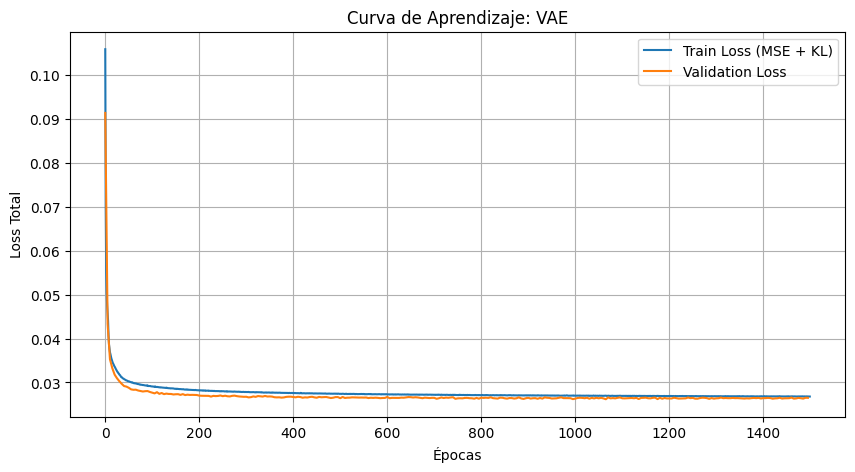

In [96]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss (MSE + KL)")
# Ajustamos los índices de validación para que coincidan con las épocas correctas
val_indices = [i * validation_freq for i in range(len(val_losses))]
plt.plot(val_indices, val_losses, label="Validation Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss Total")
plt.title("Curva de Aprendizaje: VAE")
plt.legend()
plt.grid(True)
plt.show()

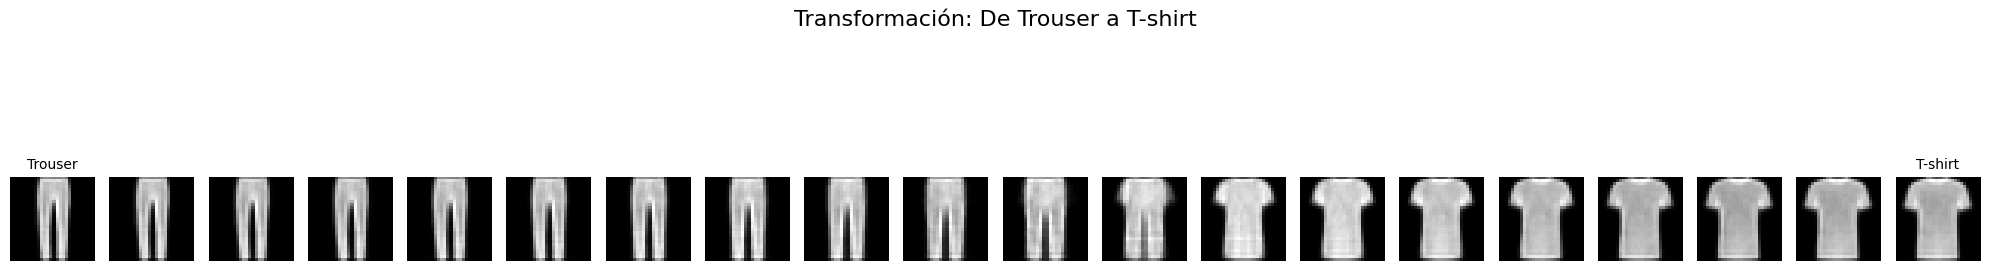

In [97]:
# 1. OBTENER VECTORES LATENTES Y ETIQUETAS DEL TEST
# model.eval() completamente inútil aquí, no hacemos forward
latent_vectors = []
all_labels = []
with torch.no_grad():
    for images, labels in test_dataloader:
        # images tiene forma [1024 (batch_size), 784] ([784, 784] el último)
        h = model.encoder_base(images)  # Pasamos por el encoder
        mu = model.fc_mu(h)             # para obtener MU (la media)
        latent_vectors.append(mu)
        all_labels.append(labels)
# lista de tensores -> tensor
latent_vectors = torch.cat(latent_vectors)  # [10 (las veces que se ejecuta el bucle)] -> [10000, 8]
all_labels = torch.cat(all_labels)          # [10] -> [10000]

# 2. CALCULAR EL "PROTOTIPO" (MEDIA) DE CADA CLASE
prototypes = []   # Media de los vectores latentes (las medias de cada imagen) de una clase
for i in range(10):
    indices = (all_labels == i).nonzero() # Filtramos los vectores que corresponden a la clase 'i'
    """
    Índices de vectores que pertenecen a la clase 0: [[   3], [  12], [  99], ..., [9968], [9986], [9987]]
    """
    latent_vectors_class_i = latent_vectors[indices]

    # Calculamos la media de esos vectores -> Prototipo
    class_mean = torch.mean(latent_vectors_class_i, dim=0)
    prototypes.append(class_mean)

# lista de tensores -> tensor
prototypes = torch.cat(prototypes)          # [10] -> [10, 8]

# 3. INTERPOLACIÓN (MORPHING)
class_start_idx = 1   # Trouser
class_end_idx   = 0   # T-shirt

# Obtenemos los vectores inicial y final
vec_start = prototypes[class_start_idx]
vec_end   = prototypes[class_end_idx]

# Generamos 20 pasos intermedios usando interpolación lineal
steps = 20
# Creamos un vector de pasos de 0 a 1 (0.0, 0.05, 0.10, ... 1.0)
alphas = torch.linspace(0, 1, steps)

# Interpolamos: Usando lerp, lo hacemos manualmente para broadcasting fácil o usamos un bucle
interpolated_vectors = []
for alpha in alphas:
    v = torch.lerp(vec_start, vec_end, alpha) # torch.lerp(start, end, weight)
    """
    torch.lerp = inicio + peso * (fin - inicio)
    Si weight = 0:    El resultado es 100% el tensor de inicio.
    Si weight = 1:    El resultado es 100% el tensor de fin.
    Si weight = 0.5:  El resultado es el punto medio exacto entre ambos.
    Si weight = 0.1:  El resultado es una mezcla (90% inicio, 10% fin).
    """
    interpolated_vectors.append(v)

interpolated_vectors = torch.stack(interpolated_vectors)  # [20] -> [20, 8]
# 4. DECODIFICAR (GENERAR IMÁGENES)
with torch.no_grad():
    generated_imgs = model.decoder(interpolated_vectors)  # [20, 784]

# 5. VISUALIZAR LA TRANSICIÓN
generated_imgs = generated_imgs.cpu().numpy()
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(20, 4))
for i in range(steps):
    ax = plt.subplot(1, steps, i + 1)
    plt.imshow(generated_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Etiquetas al principio y al final
    if    i == 0:          ax.set_title(class_names[class_start_idx], fontsize=10)
    elif  i == steps - 1:  ax.set_title(class_names[class_end_idx], fontsize=10)

plt.suptitle(f"Transformación: De {class_names[class_start_idx]} a {class_names[class_end_idx]}", fontsize=16)
plt.tight_layout()
plt.show()

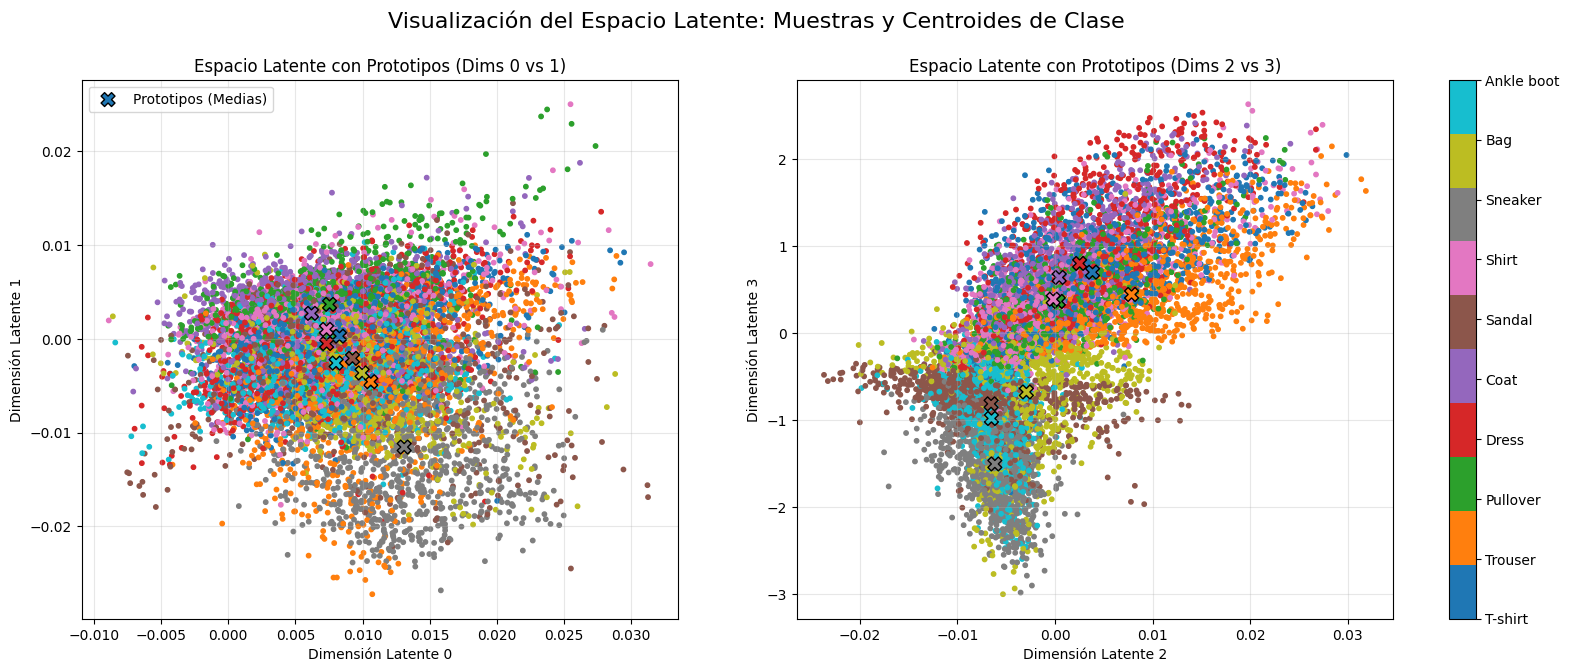

In [98]:
latent_vectors = latent_vectors.cpu()
all_labels     = all_labels.cpu()
prototypes     = prototypes.cpu()

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Creamos la figura con 2 subgráficas (Dims 0 vs 1 y Dims 2 vs 3)
fig, axs = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICA 1: Dimensión 0 vs 1 ---
# 1. Pintamos la nube de puntos (las muestras individuales)
scatter = axs[0].scatter(latent_vectors[:, 0], latent_vectors[:, 1],
                         c=all_labels, cmap='tab10', s=10)

# 2. Pintamos los PROTOTIPOS (La "Media de las Medias")
axs[0].scatter(prototypes[:, 0], prototypes[:, 1],
               c=range(10), cmap='tab10', s=100, marker='X', edgecolors='black', label='Prototipos (Medias)')

axs[0].set_xlabel("Dimensión Latente 0")
axs[0].set_ylabel("Dimensión Latente 1")
axs[0].set_title("Espacio Latente con Prototipos (Dims 0 vs 1)")
axs[0].grid(True, alpha=0.3)
axs[0].legend() # Mostramos la leyenda para identificar las X

# --- GRÁFICA 2: Dimensión 2 vs 3 ---
axs[1].scatter(latent_vectors[:, 2], latent_vectors[:, 3],
               c=all_labels, cmap='tab10', s=10)

# Prototipos encima
axs[1].scatter(prototypes[:, 2], prototypes[:, 3],
               c=range(10), cmap='tab10', s=100, marker='X', edgecolors='black')

axs[1].set_xlabel("Dimensión Latente 2")
axs[1].set_ylabel("Dimensión Latente 3")
axs[1].set_title("Espacio Latente con Prototipos (Dims 2 vs 3)")
axs[1].grid(True, alpha=0.3)

# Barra de colores lateral
cbar = fig.colorbar(scatter, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_ticks(range(10))
cbar.set_ticklabels(class_names)

plt.suptitle("Visualización del Espacio Latente: Muestras y Centroides de Clase", fontsize=16)
plt.show()

# La Importancia de la Divergencia Kullback-Leibler (KL) en este problema

En este ejercicio hemos transformado un Autoencoder estándar en un **Variational Autoencoder (VAE)**. La diferencia matemática fundamental ha sido la inclusión del término de **Divergencia Kullback-Leibler (KL)** en la función de pérdida. Pero, ¿de qué nos ha servido realmente en la práctica?

### Organización del Espacio Latente (Regularización)
Si hubiéramos entrenado un Autoencoder normal (solo minimizando el error de reconstrucción), la red habría aprendido a memorizar los puntos del dataset colocándolos en lugares arbitrarios del espacio latente, dejando grandes "huecos" vacíos entre ellos.

La **Divergencia KL** actúa como un **regularizador** que fuerza a la red a organizar el espacio latente siguiendo una distribución específica (una distribución Normal Estándar $\mathcal{N}(0,1)$).
* **Visualmente:** Esto es lo que provoca que en nuestras gráficas de dispersión veamos que todas las clases se agrupan formando una "nube" compacta centrada en el origen $(0,0)$, en lugar de estar dispersas por todo el plano.

Esto tiene aspectos muy positivos:

* Elimina "Huecos" (Continuidad): Al forzar a todos los puntos a estar juntos en una bola, el modelo se asegura de que no haya espacios vacíos entre las clases. Esto permite que, al hacer interpolaciones (morphing), siempre pases por zonas válidas. Si los puntos estuvieran muy separados (como en un Autoencoder normal), al pasar por el medio el decoder generaría ruido o basura.

* Sabemos dónde buscar (Generación): Si queremos crear una prenda de ropa nueva que no existe, sabemos dónde buscar: cerca del $(0,0)$. Si la distribución tuviera una forma rara o dispersa, no sabríamos qué números aleatorios meterle al decoder para obtener algo con sentido.

## El único riesgo (El lado "Negativo")
Hay un fenómeno llamado "Colapso Posterior" (Posterior Collapse), que ocurre si la fuerza que los empuja al centro $(0,0)$ es demasiado fuerte (por ejemplo, si el parámetro alpha de la KL es muy alto). El encoder deja de codificar información útil (ignora la imagen de entrada) y el decoder solo aprende a generar la "imagen promedio" del dataset (una mancha gris con forma de ropa), porque todos los códigos latentes son iguales.

# PRUEBA CON ALPHA = 0 => Sin usar la Divergencia Kullback-Leibler (KL)


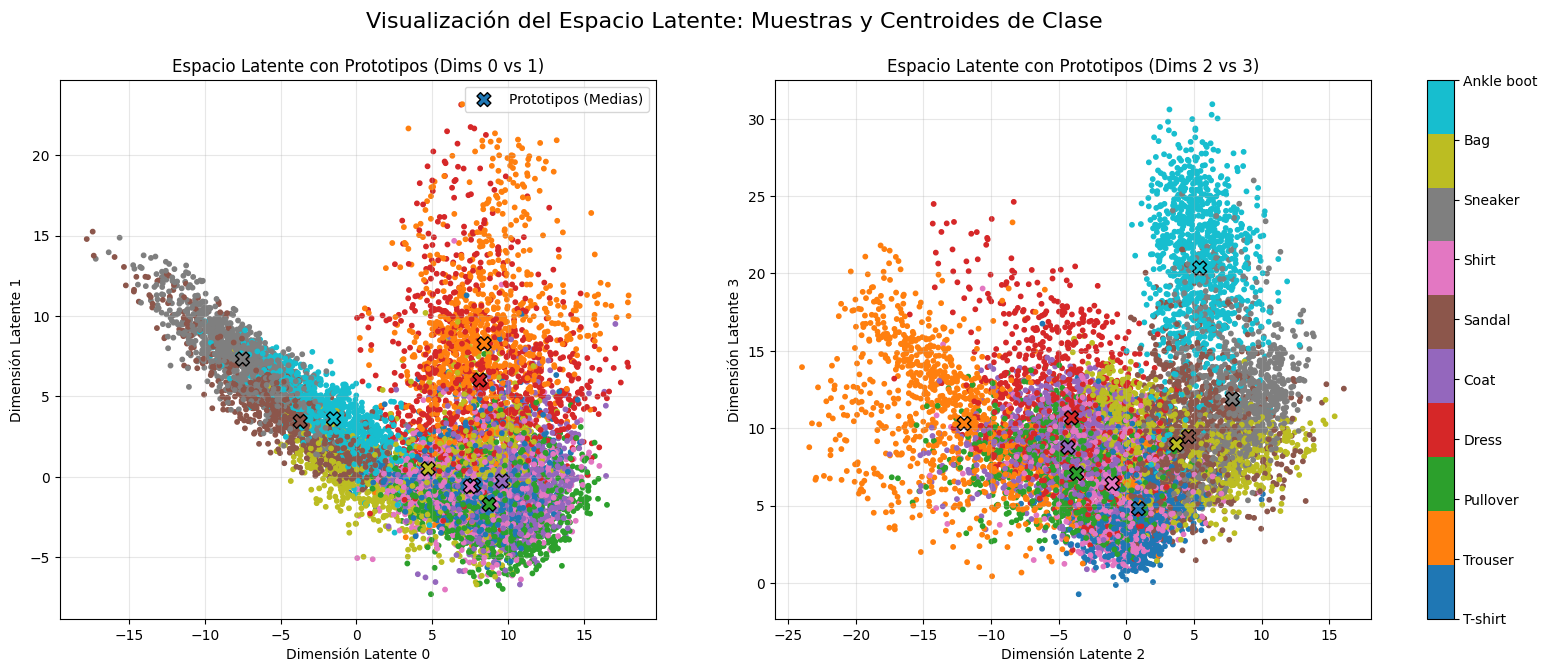